In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np


# Path to your log file
log_file_list = ['../work/experiments/stellar-core/cp_4/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/cp_8/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/cp_16/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/cp_48/tsm-sc-001/node2/stellar-core.log', ]


for log_file in log_file_list:
    print(log_file)
    # Regex patterns
    propose_pattern = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Received PROPOSE block (\w+) at view (\d+)")
    commit_pattern  = re.compile(r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*Committed block (\w+) at view (\d+)")
    
    # Dictionaries to hold times
    propose_times = {}
    commit_times = {}
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                propose_times[(block, view)] = ts
            
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                commit_times[(block, view)] = ts
    
    # Match proposals to commits → compute latency
    latencies = []
    commit_timestamps = []
    for key, ctime in commit_times.items():
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            latencies.append({
                "block": key[0],
                "view": key[1],
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
    
    if not commit_timestamps:
        print("No commits found.")
        exit()
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    commit_seconds = [(t - start_time).total_seconds() for t in commit_timestamps]
    
    # DataFrame for throughput
    df = pd.DataFrame({"time_sec": commit_seconds, "count": 1})
    df.set_index("time_sec", inplace=True)
    
    # Throughput = commits per second (resampled)
    throughput = df["count"].groupby(df.index.round()).sum()
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (blocks/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Blocks/sec")
    # plt.title("Throughput vs Time")
    # # plt.grid(True)
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(lat_df["time_sec"], lat_df["latency"], "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency")
    # # plt.grid(True)
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    print(np.average(throughput.values[-60:]))
    print(np.average(np.array(lat_df["latency"])[-60:]))

../work/experiments/stellar-core/cp_4/tsm-sc-001/node2/stellar-core.log
72.48333333333333
0.003
../work/experiments/stellar-core/cp_8/tsm-sc-001/node2/stellar-core.log
69.16666666666667
0.0019500000000000001
../work/experiments/stellar-core/cp_16/tsm-sc-001/node2/stellar-core.log
54.11666666666667
0.005100000000000001
../work/experiments/stellar-core/cp_48/tsm-sc-001/node2/stellar-core.log
18.783333333333335
0.010683333333333333


Processing: ../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log
Total proposals received: 12511
Total commits: 12504
COLLECT views found: 501
Normal consensus commits: 11503


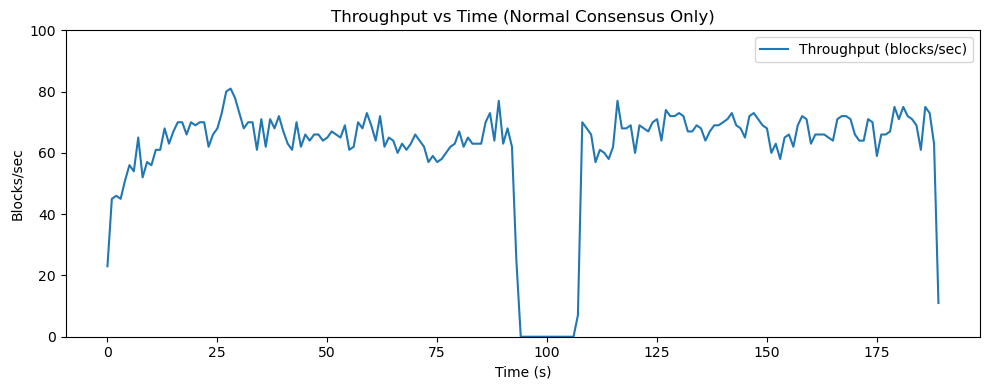

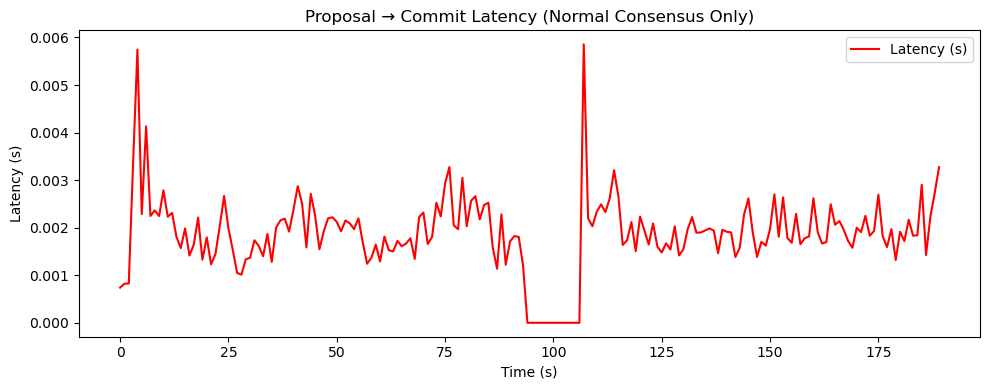


=== STATISTICS (Last 60 commits) ===
Average throughput: 67.08 blocks/sec
Average latency: 0.0027 sec
Average latency: 2.73 ms

=== OVERALL STATISTICS ===
Average throughput: 60.54 blocks/sec
Average latency: 0.0020 sec
Average latency: 1.96 ms
Min latency: 0.00 ms
Max latency: 23.00 ms
Processing: ../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log
Total proposals received: 12089
Total commits: 12175
COLLECT views found: 397
Normal consensus commits: 11015


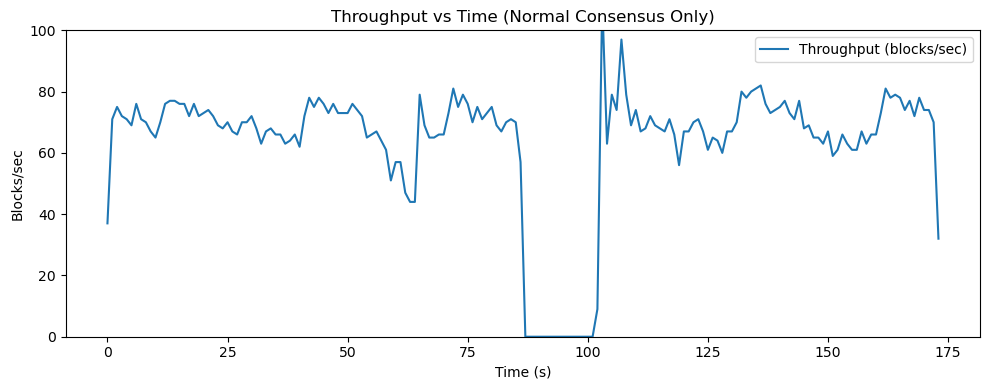

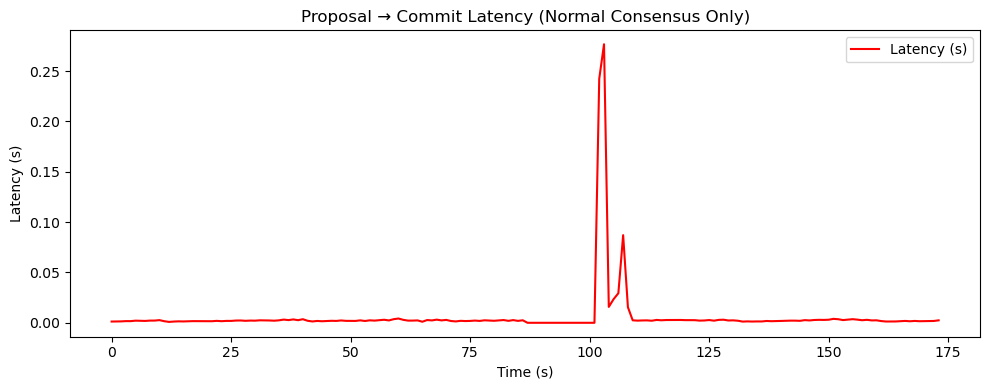


=== STATISTICS (Last 60 commits) ===
Average throughput: 69.33 blocks/sec
Average latency: 0.0021 sec
Average latency: 2.05 ms

=== OVERALL STATISTICS ===
Average throughput: 63.30 blocks/sec
Average latency: 0.0063 sec
Average latency: 6.34 ms
Min latency: 0.00 ms
Max latency: 489.00 ms
Processing: ../work/experiments/stellar-core/collection_16/tsm-sc-001/node2/stellar-core.log
Total proposals received: 7331
Total commits: 7334
COLLECT views found: 454
Normal consensus commits: 6065


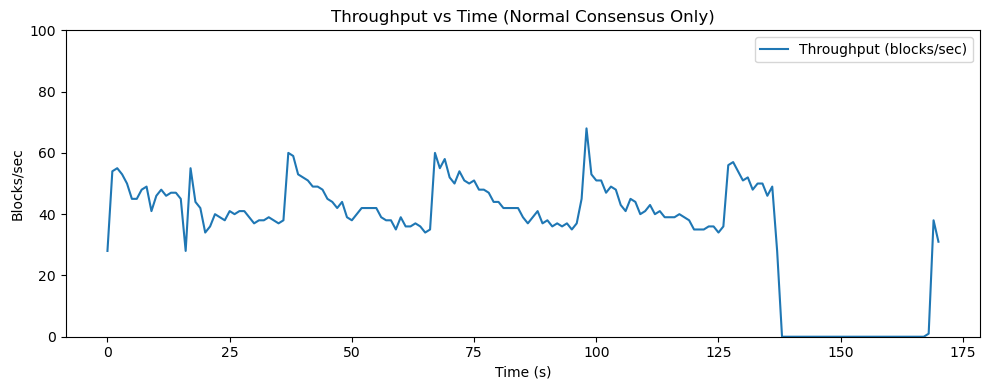

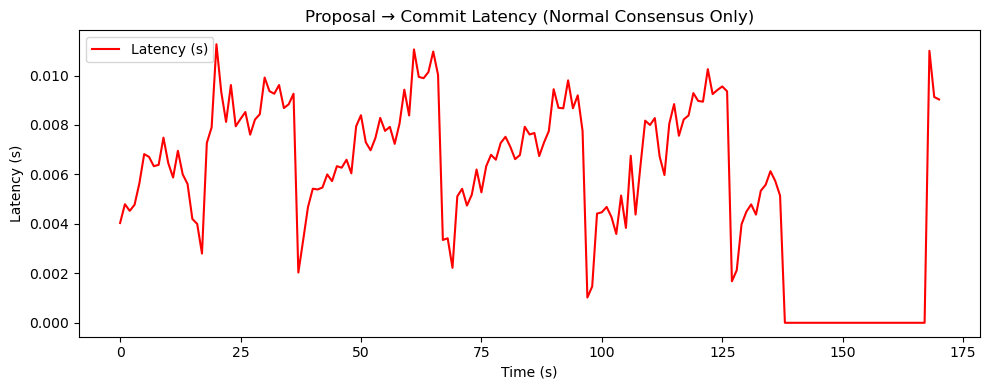


=== STATISTICS (Last 60 commits) ===
Average throughput: 20.27 blocks/sec
Average latency: 0.0092 sec
Average latency: 9.22 ms

=== OVERALL STATISTICS ===
Average throughput: 35.47 blocks/sec
Average latency: 0.0066 sec
Average latency: 6.59 ms
Min latency: 0.00 ms
Max latency: 60.00 ms


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file


# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_4/tsm-sc-001/node2/stellar-core.log', \
                '../work/experiments/stellar-core/collection_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/collection_16/tsm-sc-001/node2/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # Regex patterns
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+)"
    )
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times
    propose_times = {}
    commit_times = {}
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                commit_times[(block, view)] = ts
    
    print(f"Total proposals received: {len(propose_times)}")
    print(f"Total commits: {len(commit_times)}")
    print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency
            })
            commit_timestamps.append(ctime)
    
    if not commit_timestamps:
        print("No normal consensus commits found.")
        continue
    
    print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    commit_seconds = [(t - start_time).total_seconds() for t in commit_timestamps]
    
    # DataFrame for throughput
    df = pd.DataFrame({"time_sec": commit_seconds, "count": 1})
    df.set_index("time_sec", inplace=True)
    
    # Throughput = commits per second (resampled)
    throughput = df["count"].groupby(df.index.round()).sum()

    #  Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)

    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())





        
    
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second (in case multiple commits in same second)
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)



    throughput_list.append(throughput)
    latency_list.append(latency_series)

    
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (blocks/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Blocks/sec")
    plt.ylim(0,100)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()



    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("latency.png", dpi=150)
    plt.show()
    
    # ---- Statistics ----
    print(f"\n=== STATISTICS (Last 60 commits) ===")
    print(f"Average throughput: {np.average(throughput.values[-60:]):.2f} blocks/sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]):.4f} sec")
    print(f"Average latency: {np.average(np.array(lat_df['latency'])[-60:]) * 1000:.2f} ms")
    
    print(f"\n=== OVERALL STATISTICS ===")
    print(f"Average throughput: {np.average(throughput.values):.2f} blocks/sec")
    print(f"Average latency: {np.average(lat_df['latency']):.4f} sec")
    print(f"Average latency: {np.average(lat_df['latency']) * 1000:.2f} ms")
    print(f"Min latency: {np.min(lat_df['latency']) * 1000:.2f} ms")
    print(f"Max latency: {np.max(lat_df['latency']) * 1000:.2f} ms")


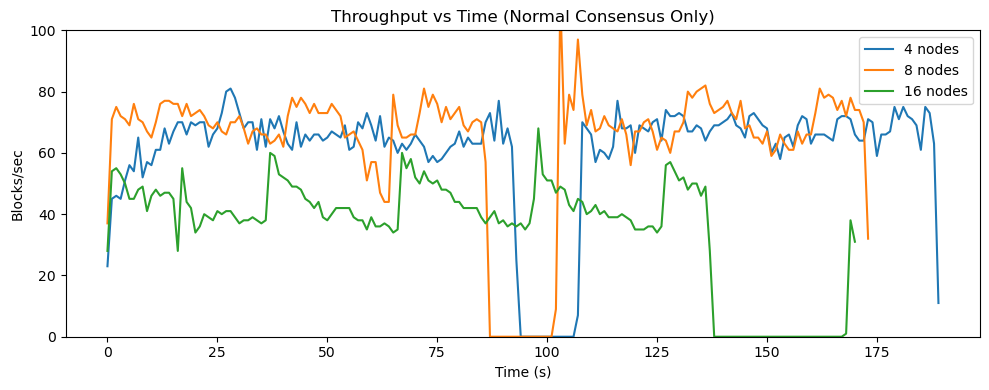

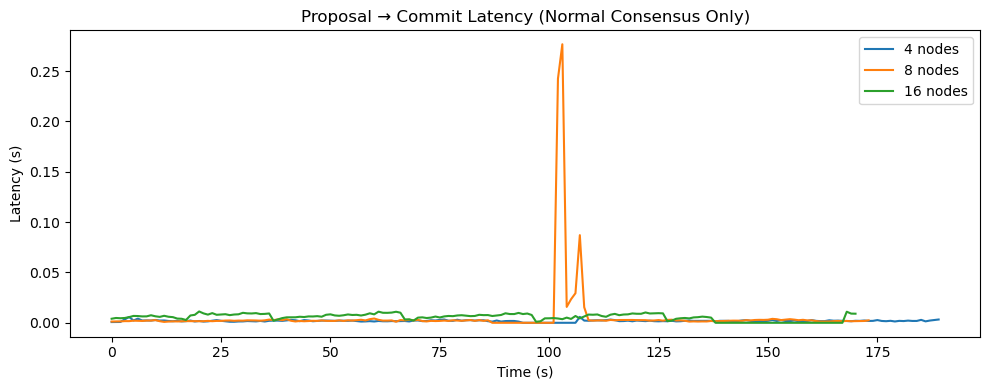

In [35]:


node_list = [4,8, 16]
# ---- Plot Throughput ----
plt.figure(figsize=(10, 4))
for i, throughput in enumerate(throughput_list):
    plt.plot(throughput.index, throughput.values, "-", label=str(node_list[i]) + " nodes")

plt.xlabel("Time (s)")
plt.ylabel("Blocks/sec")
plt.ylim(0,100)
plt.title("Throughput vs Time (Normal Consensus Only)")
plt.legend()
plt.tight_layout()
plt.savefig("throughput.png", dpi=150)
plt.show()




# ---- Plot Latency ----
plt.figure(figsize=(10, 4))
for i, latency_series in enumerate(latency_list) :
    plt.plot(latency_series.index, latency_series.values, "-", label=str(node_list[i]) + " nodes")
plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
plt.title("Proposal → Commit Latency (Normal Consensus Only)")
plt.legend()
plt.tight_layout()
plt.savefig("latency.png", dpi=150)
plt.show()